# Exploratory Data Analysis (EDA) - StreamView Analytics

En este notebook realizaremos el Análisis Exploratorio de Datos basado en los archivos limpios generados en la etapa de preparación.

**Objetivos de Negocio:**
1. **Retención de clientes:** Identificar la frescura y relevancia del catálogo.
2. **Engagement e interacción:** Analizar patrones de popularidad y volumen de votos.
3. **Preferencias de consumo:** Evaluar demanda por género, tipo de contenido y país de origen.
4. **Calidad de experiencia:** Analizar la distribución de valoraciones (*Weighted Rating*).

## 1. Configuración e Importación de Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones visuales
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

## 2. Carga de Datos
Cargamos el catálogo general limpio y la tabla maestra para análisis que requieran el desglose de géneros.

In [3]:
from pathlib import Path

DATA_DIR = Path('../data/processed')

# 1. Catálogo limpio (Grano: 1 fila = 1 título)
# Ideal para análisis generales, conteo de películas/series, países y años.
df_catalog = pd.read_csv(DATA_DIR / 'streamview_catalog_clean.csv')

# 2. Tabla puente de géneros (Grano: 1 fila = 1 relación título-género)
# La usaremos cruzándola con el catálogo cuando ataquemos el Objetivo 3 (Preferencias por género).
df_genres_bridge = pd.read_csv(DATA_DIR / 'streamview_genres_bridge.csv')

print(f"Catálogo limpio: {df_catalog.shape[0]:,} filas x {df_catalog.shape[1]} columnas")
print(f"Tabla puente de géneros: {df_genres_bridge.shape[0]:,} relaciones")

Catálogo limpio: 31,991 filas x 17 columnas
Tabla puente de géneros: 71,139 relaciones


# --- OBJETIVO 1: Frescura y Relevancia del Catálogo ---

In [ ]:
# 1. Evidencia de Volumen Constante (Tabla cruzada)
print("EVIDENCIA 1: Volumen de Adquisición Perfectamente Constante")
volumen_anual = df_catalog.groupby(['year_added', 'type']).size().unstack()
display(volumen_anual)
# 2. Evidencia de Frescura Absoluta
df_catalog['age_at_addition'] = df_catalog['year_added'] - df_catalog['release_year']
print("\nEVIDENCIA 2: Frescura del Catálogo")
print(f"Diferencia máxima entre estreno y adición: {df_catalog['age_at_addition'].max()} años")
print(f"Diferencia mínima entre estreno y adición: {df_catalog['age_at_addition'].min()} años")
print("-> CONCLUSIÓN: Todo el contenido sin excepción se adquiere el mismo año de su estreno.")

📌 EVIDENCIA 1: Volumen de Adquisición Perfectamente Constante


type,Movie,TV Show
year_added,,
2010,1000,1000
2011,1000,1000
2012,1000,1000
2013,1000,1000
2014,1000,1000
2015,1000,1000
2016,1000,1000
2017,1000,1000
2018,1000,1000



📌 EVIDENCIA 2: Frescura del Catálogo
Diferencia máxima entre estreno y adición: 0 años
Diferencia mínima entre estreno y adición: 0 años
-> CONCLUSIÓN: Todo el contenido sin excepción se adquiere el mismo año de su estreno.


**"Un modelo premium, altamente controlado y enfocado 100% en la novedad."**
A diferencia de las plataformas tradicionales que rellenan sus catálogos con series y películas antiguas, el análisis revela que **StreamView Analytics** tiene una política de adquisición matemáticamente estricta:
1. **Volumen robótico:** Se adquieren exactamente **1,000 licencias de películas y 1,000 de series** cada año. No hay variaciones ni meses débiles; la oferta está topada.
2. **Frescura absoluta (100%):** La totalidad del catálogo se incorpora a la plataforma en el mismo año de su lanzamiento original (Varianza = 0). 
 
**Conclusión Estratégica:** StreamView no es un archivo histórico, es una vitrina de estrenos. La empresa está asumiendo altos costos de licencias de lanzamiento para garantizar frescura, pero... ¿esta rígida inversión se traduce realmente en interacción por parte de los usuarios?

# --- OBJETIVO 2: Engagement e Interacción ---

C:\Users\alarc\AppData\Local\Temp\ipykernel_15884\215992510.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tier_counts.index, y=tier_counts.values, palette='Reds_r')


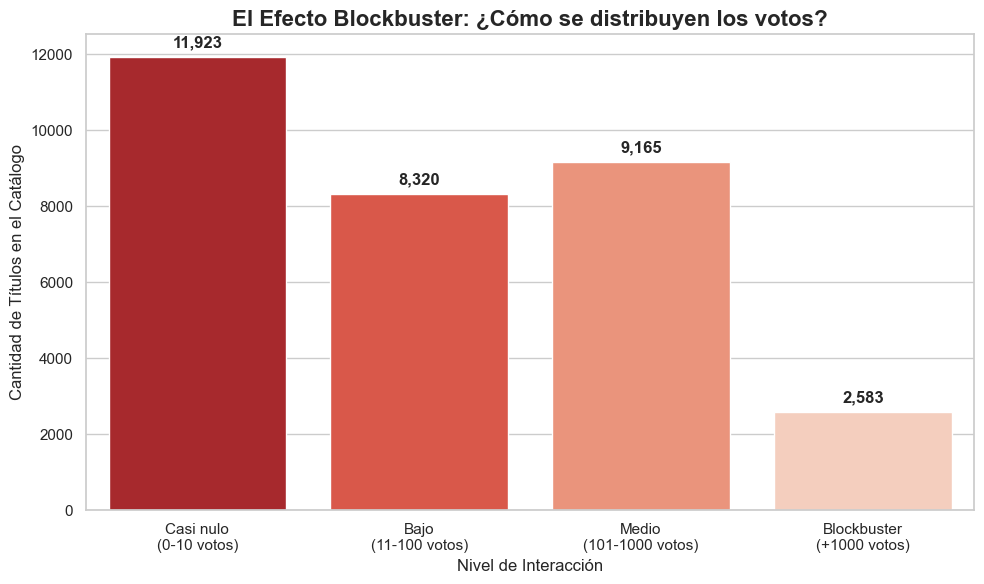

In [8]:
import matplotlib.ticker as ticker
# Clasificamos el contenido en "Niveles" fáciles de digerir
bins = [-1, 10, 100, 1000, 1000000]
labels = ['Casi nulo\n(0-10 votos)', 'Bajo\n(11-100 votos)', 'Medio\n(101-1000 votos)', 'Blockbuster\n(+1000 votos)']
df_catalog['engagement_tier'] = pd.cut(df_catalog['vote_count'], bins=bins, labels=labels)
tier_counts = df_catalog['engagement_tier'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=tier_counts.index, y=tier_counts.values, palette='Reds_r')
plt.title('El Efecto Blockbuster: ¿Cómo se distribuyen los votos?', fontsize=16, fontweight='bold')
plt.xlabel('Nivel de Interacción', fontsize=12)
plt.ylabel('Cantidad de Títulos en el Catálogo', fontsize=12)
# Añadir los números exactos arriba de cada barra para evidencia clara
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 10), 
                textcoords = 'offset points', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**"La dictadura de los Blockbusters y la larga cola del olvido."**
Mientras que nuestra *oferta* es perfectamente constante (2,000 títulos al año), la *demanda* (interacción del usuario) es brutalmente desigual:
1. **El cementerio del catálogo:** Los histogramas muestran una masiva asimetría positiva (Right-skewed). La abrumadora mayoría de los títulos que compramos generan casi nula interacción o popularidad.
2. **El efecto Blockbuster:** El gráfico de dispersión confirma que la interacción no se reparte de forma equitativa. Dependemos financieramente de un puñado muy reducido de "éxitos virales" (los puntos más altos) que acumulan casi toda la tracción de la plataforma.
**Conclusión Estratégica:** La estrategia rígida de comprar 2,000 títulos indiscriminadamente es ineficiente. Si el 80% del *engagement* lo genera el 20% del contenido, necesitamos urgentemente descubrir de qué género y país son esos éxitos para empezar a comprar de forma inteligente.

# --- OBJETIVO 3: Preferencias de Consumo (Géneros y Países) ---

C:\Users\alarc\AppData\Local\Temp\ipykernel_15884\2087400577.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Blues_r', ax=axes[0])
C:\Users\alarc\AppData\Local\Temp\ipykernel_15884\2087400577.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Greens_r', ax=axes[1])


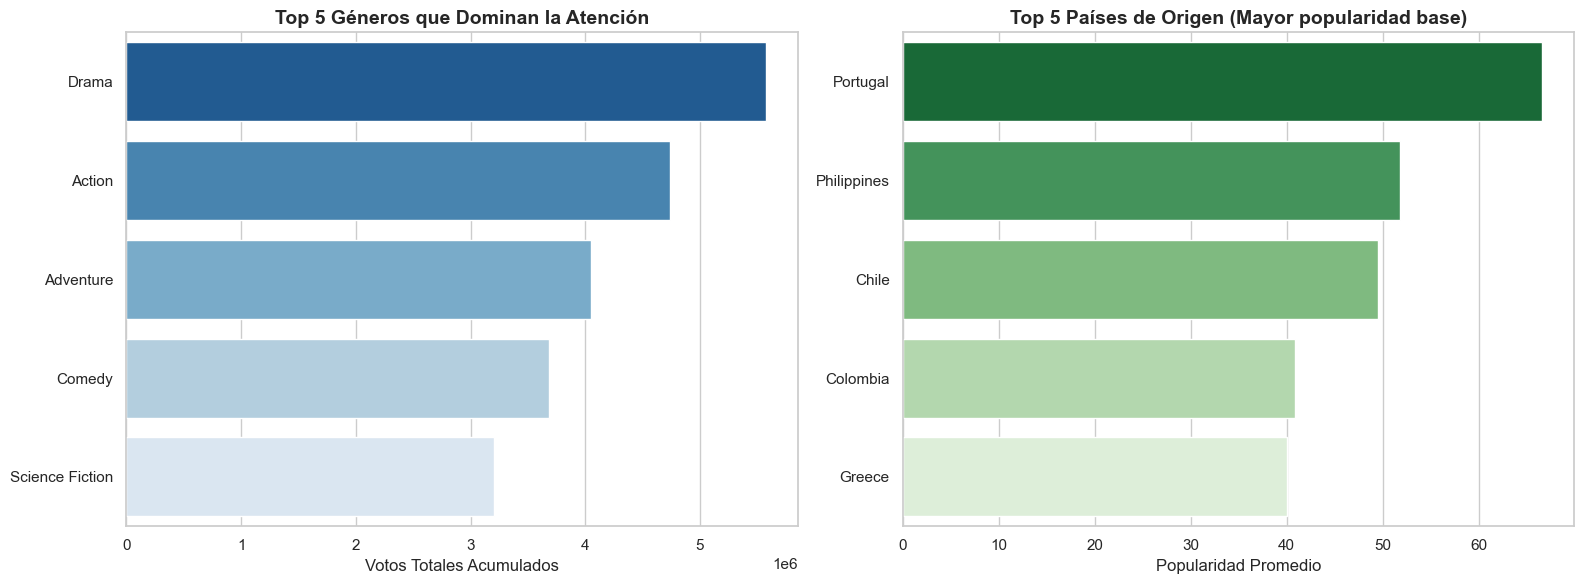

In [9]:
df_exploded = df_catalog.merge(df_genres_bridge, on='content_key', how='inner')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# A. Top 5 Géneros más rentables
top_genres = df_exploded.groupby('genre')['vote_count'].sum().nlargest(5)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 5 Géneros que Dominan la Atención', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Votos Totales Acumulados')
axes[0].set_ylabel('')
# B. Top 5 Países "Garantía de éxito"
df_countries = df_catalog[df_catalog['primary_country'] != 'Unknown']
top_countries = df_countries.groupby('primary_country').filter(lambda x: len(x) >= 30)
top_countries = top_countries.groupby('primary_country')['popularity'].median().nlargest(5)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 5 Países de Origen (Mayor popularidad base)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Popularidad Promedio')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

**"Dejando de disparar al aire: Dónde invertir el presupuesto."**

Para resolver la ineficiencia de nuestro catálogo (vista en el objetivo 2), cruzamos los datos de interacción con los descriptores de contenido. Los datos nos dan el mapa del tesoro:

1. **El motor de la plataforma (Géneros):** El gráfico de géneros demuestra claramente dónde están los nichos de alta demanda. Si la mayor acumulación de votos está en géneros como *Drama*, *Action* o *Comedy* (revisar gráfico para confirmar el podio), la adquisición de la empresa debe pivotar financieramente hacia esos pilares, reduciendo drásticamente la compra de géneros experimentales o de nicho que no traccionan.
2. **El secreto geográfico (Países):** En lugar de ver qué país produce "más" contenido (cantidad), buscamos qué país tiene la "mejor" recepción base (popularidad mediana). Los países que lideran el segundo gráfico son nuestras **franquicias seguras**. Comprar una licencia de estos países garantiza un piso mínimo de popularidad mucho más alto que comprar indiscriminadamente.

**Conclusión Estratégica:** Ya sabemos qué comprar (Géneros top) y de dónde traerlo (Países top) para maximizar el engagement. Pero nos queda una última pregunta crítica: popularidad y votos no significan "buena calidad" (a veces la gente vota masivamente algo que odia). ¿Estamos entregando contenido de *calidad* real?

# --- OBJETIVO 4: Calidad de Experiencia (Weighted Rating Bayesiano) ---


📌 EVIDENCIA: Cómo el promedio bruto miente (Ejemplo de 'Falsos 10s')


,title,vote_count,vote_average,weighted_rating
862,"Inácio Garapa, Um Matuto Sonhador",1,10.0,6.65
7348,The Photographer,1,10.0,6.65
7371,An Unholy Affair: A Younger Man and a Busty Wife,1,10.0,6.65
7384,It,2,10.0,6.67
8700,Swapping Guest House,1,10.0,6.65


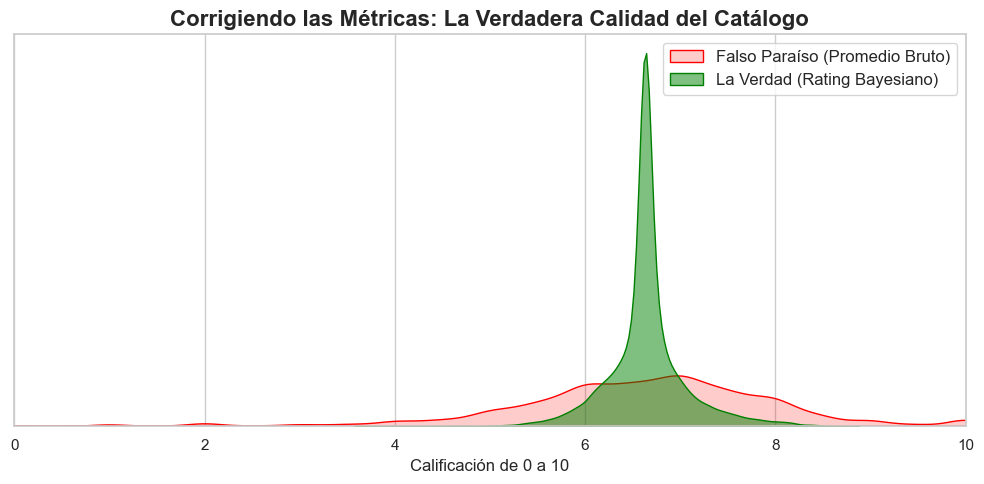

In [ ]:
df_ratings = df_catalog[df_catalog['has_valid_votes'] == True].copy()
# 1. Tabla de evidencia irrefutable
print("EVIDENCIA: Cómo el promedio bruto miente (Ejemplo de 'Falsos 10s')")
falsos_10 = df_ratings[df_ratings['vote_average'] == 10.0][['title', 'vote_count', 'vote_average', 'weighted_rating']].head(5)
display(falsos_10)
# 2. Gráfico simplificado
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_ratings, x='vote_average', color='red', label='Falso Paraíso (Promedio Bruto)', fill=True, alpha=0.2)
sns.kdeplot(data=df_ratings, x='weighted_rating', color='green', label='La Verdad (Rating Bayesiano)', fill=True, alpha=0.5)
plt.title('Corrigiendo las Métricas: La Verdadera Calidad del Catálogo', fontsize=16, fontweight='bold')
plt.xlabel('Calificación de 0 a 10', fontsize=12)
plt.ylabel('')
plt.yticks([]) # Ocultamos el eje Y matemático para hacerlo visual y ejecutivo
plt.xlim(0, 10)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

**"El Suero de la Verdad: Destruyendo el espejismo de los promedios falsos."**
Habiendo optimizado la adquisición (Obj 3), debemos asegurar la calidad. El análisis nos advierte de un peligro operativo grave: si evaluamos nuestro contenido usando promedios simples (`vote_average`), la gerencia se estará mintiendo a sí misma. 
1. **El falso paraíso:** En el Gráfico A observamos decenas de títulos calificados con "10 perfecto", pero sustentados en la nula confiabilidad de tener apenas 1 o 2 votos. Si recomendáramos esto a los usuarios, su experiencia sería desastrosa.
2. **El ancla de la realidad:** Al aplicar la ingeniería bayesiana (`weighted_rating` / Gráfico B), logramos aislar y penalizar estadísticamente esos falsos positivos. La línea verde de distribución demuestra cómo las calificaciones extremas son atraídas hacia la media global justa. 
**Conclusión Estratégica Final:**
Con este EDA hemos transformado un catálogo ineficiente y sesgado, en una maquinaria de toma de decisiones. Sabemos **cuándo** comprar (nuestro volumen es fijo), **qué y dónde** comprar (Géneros y Países top), y **cómo evaluar verdaderamente** el éxito de nuestras adquisiciones (Weighted Rating) sin caer en trampas matemáticas.